In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

import os
from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

# Load and pre-processing

In [8]:
lab = pd.read_csv('../Dataset/self_assessments.csv', sep=";", header=0)
most_st = lab.tail(1)
lab.drop(lab.tail(1).index,inplace=True) 

tasks = ["Breathing", "Video1", "Video2", "Counting1", "Counting2", 
         "Stroop", "Math", "Speaking", "Reading", "Counting3", "Relax"]
subjects = lab.columns[1:]

lab[subjects] = lab[subjects].astype(float)
lab.tail()

,Tasks,hh2e,wfsl,37ir,hvpa,ql3b,r0a3,qx2o,wssm,ctzy,...,y8c3,g7r2,f6q3,e5p4,d4n6,c3m7,b2l8,a1k9,t6v9,b9w0
39,Counting3_arousal,NaN,6.0,8.0,8.0,10.0,6.0,6.0,6.0,9.0,...,5.0,4.0,3.0,5.0,6.0,5.0,6.0,7.0,8.0,8.0
40,Relax_relax,6.0,NaN,7.0,6.0,10.0,10.0,4.0,7.0,9.0,...,9.0,8.0,9.0,8.0,5.0,7.0,6.0,8.0,3.0,2.0
41,Relax_stress,6.0,NaN,1.0,2.0,0.0,1.0,5.0,0.0,1.0,...,0.0,0.0,1.0,2.0,3.0,5.0,5.0,3.0,3.0,5.0
42,Relax_valence,NaN,NaN,7.0,6.0,8.0,6.0,5.0,7.0,5.0,...,6.0,5.0,8.0,7.0,5.0,6.0,7.0,8.0,5.0,5.0
43,Relax_arousal,NaN,NaN,6.0,5.0,8.0,2.0,3.0,0.0,1.0,...,4.0,2.0,1.0,3.0,3.0,7.0,6.0,5.0,0.0,4.0


In [3]:
keys = [str(i)+"_"+str(j) for i in subjects for j in tasks]
labels_dict = dict.fromkeys(keys)

for l in labels_dict: 
    lsplit = l.split('_')
    s, t = lsplit[0], lsplit[1]
    labels_dict[l] = list(lab[lab["Tasks"].str.contains(t)][s])
    
labels = pd.DataFrame.from_dict(labels_dict)
labels.index=['relax', 'stress', 'valence', 'arousal']
labels.head()

,hh2e_Breathing,hh2e_Video1,hh2e_Video2,hh2e_Counting1,hh2e_Counting2,hh2e_Stroop,hh2e_Math,hh2e_Speaking,hh2e_Reading,hh2e_Counting3,...,b9wo_Video1,b9wo_Video2,b9wo_Counting1,b9wo_Counting2,b9wo_Stroop,b9wo_Math,b9wo_Speaking,b9wo_Reading,b9wo_Counting3,b9wo_Relax
relax,6.0,8.0,7.0,6.0,3.0,6.0,5.0,6.0,8.0,5.0,...,5.0,4.0,3.0,1.0,3.0,3.0,2.0,2.0,1.0,2.0
stress,5.0,2.0,3.0,5.0,7.0,6.0,6.0,6.0,4.0,7.0,...,2.0,3.0,4.0,6.0,6.0,6.0,7.0,6.0,7.0,5.0
valence,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.0,5.0,5.0,3.0,4.0,5.0,4.0,5.0,5.0,5.0
arousal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,7.0,9.0,9.0,9.0,9.0,9.0,5.0,8.0,4.0


In [4]:
labels_t = labels.transpose()

# Self-assessment distributions
#### Across all tasks and subjects

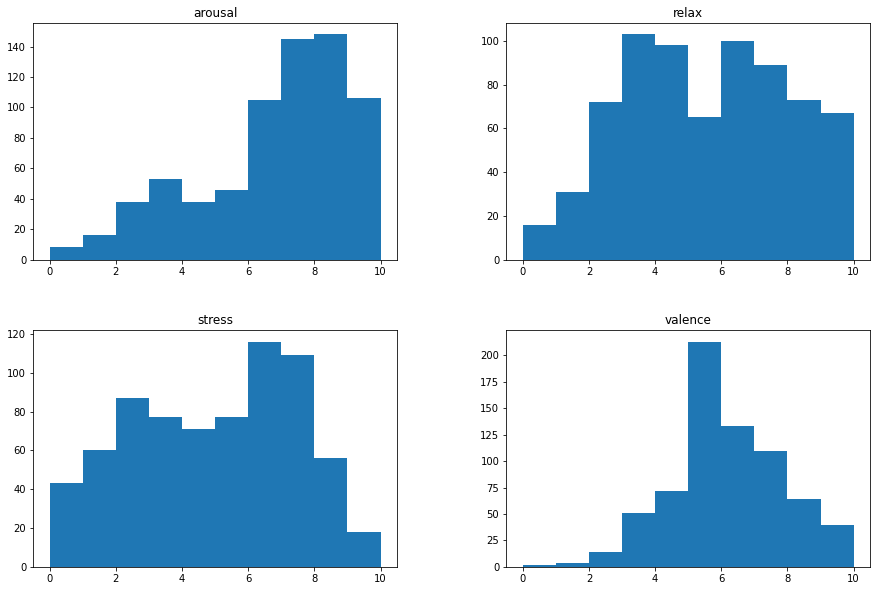

In [5]:
hist_all = labels_t.hist(grid=False, figsize = (15,10))

#### Grouped by subject, across all tasks and assessments

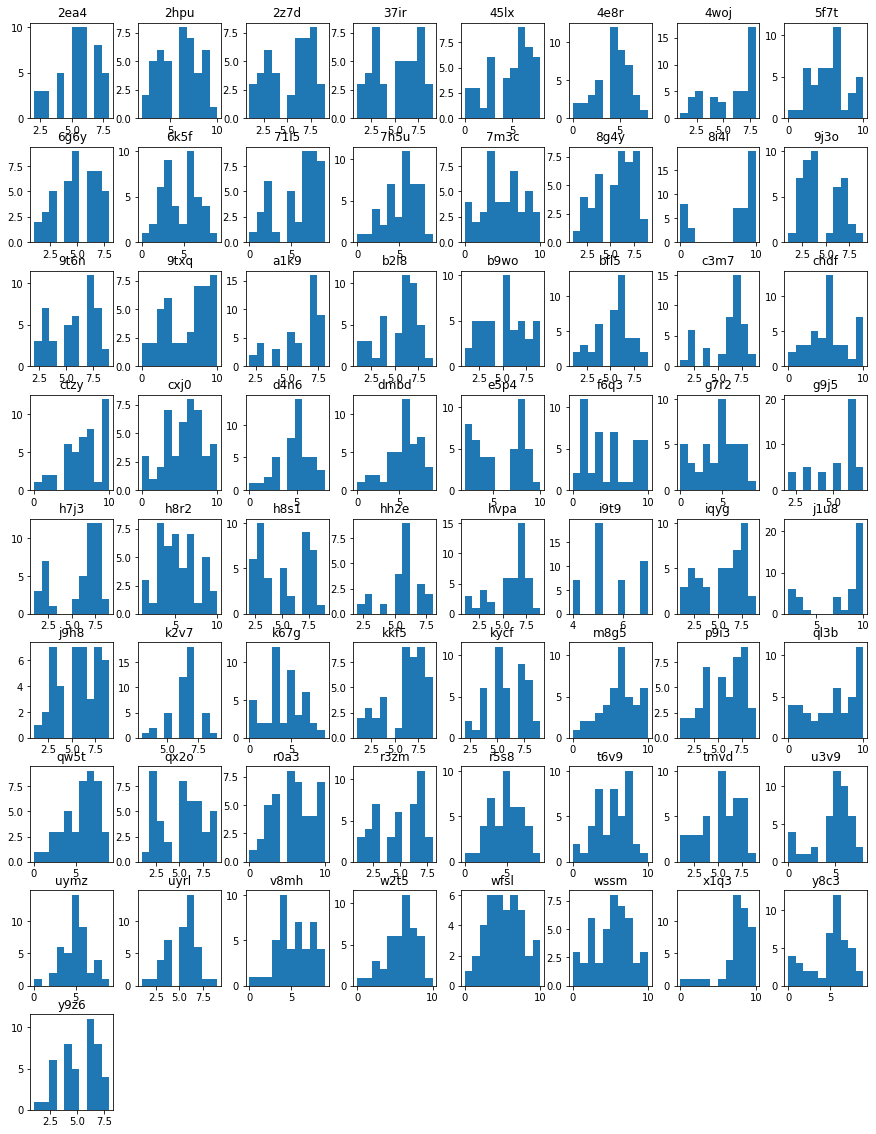

In [6]:
hist_ = lab.hist(grid=False, figsize = (15,20))

#### Grouped by assessment, accross all tasks and for each subject

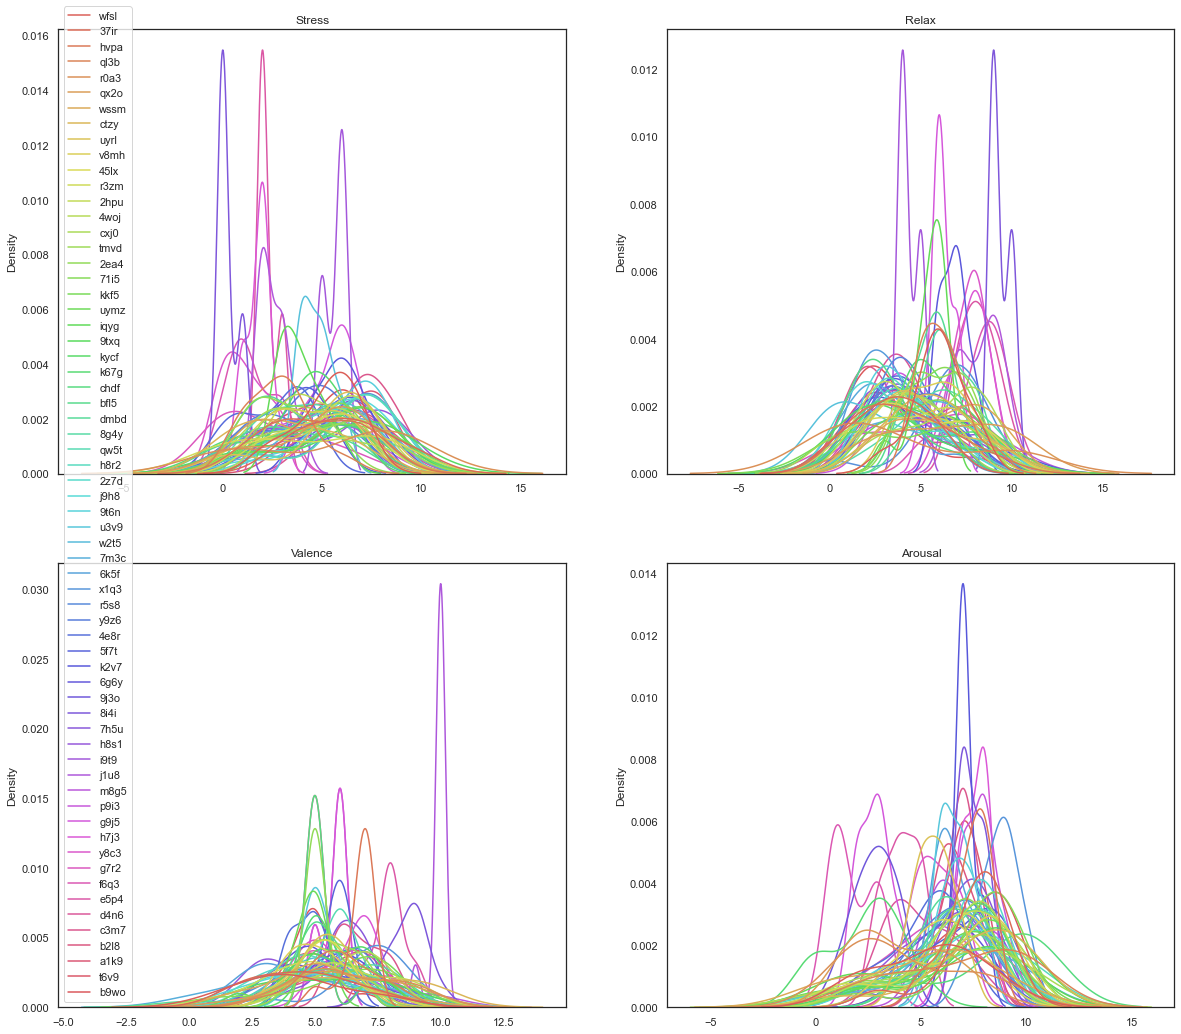

In [86]:
lab_stress = lab[lab["Tasks"].str.contains("stress")]
lab_relax = lab[lab["Tasks"].str.contains("relax")]
lab_valence = lab[lab["Tasks"].str.contains("valence")].drop(columns = "hh2e")
lab_arousal = lab[lab["Tasks"].str.contains("arousal")].drop(columns = "hh2e")

fig, axs = plt.subplots(2,2, figsize=(20, 18))
sns.kdeplot(data=lab_stress, palette='hls', legend=False, ax=axs[0,0])
axs[0,0].title.set_text('Stress')
sns.kdeplot(data=lab_relax, palette='hls',legend=False, ax=axs[0,1])
axs[0,1].title.set_text('Relax')
sns.kdeplot(data=lab_valence, palette='hls', ax=axs[1,0])
axs[1,0].title.set_text('Valence')
sns.kdeplot(data=lab_arousal,palette='hls',legend=False, ax=axs[1,1])
axs[1,1].title.set_text('Arousal')

# Intercorrelations
#### Stress with respect to valence and arousal

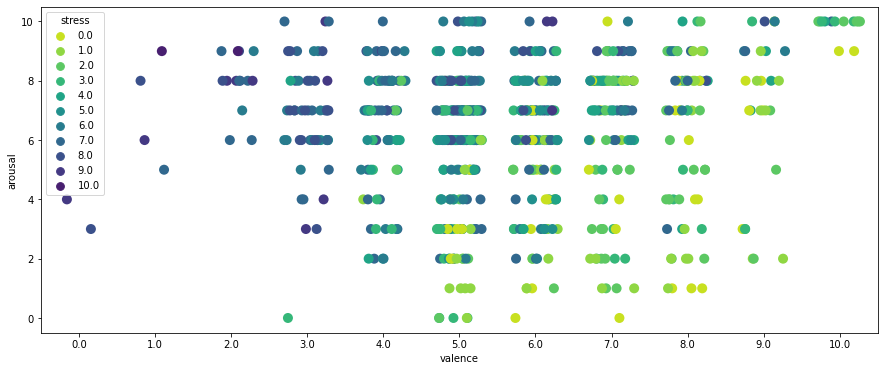

In [9]:
plt.figure(figsize=(15,6))
sns.stripplot(data =labels_t, x="valence", y="arousal", hue="stress",
              palette ="viridis_r" , jitter=0.3, size=10)
plt.show()

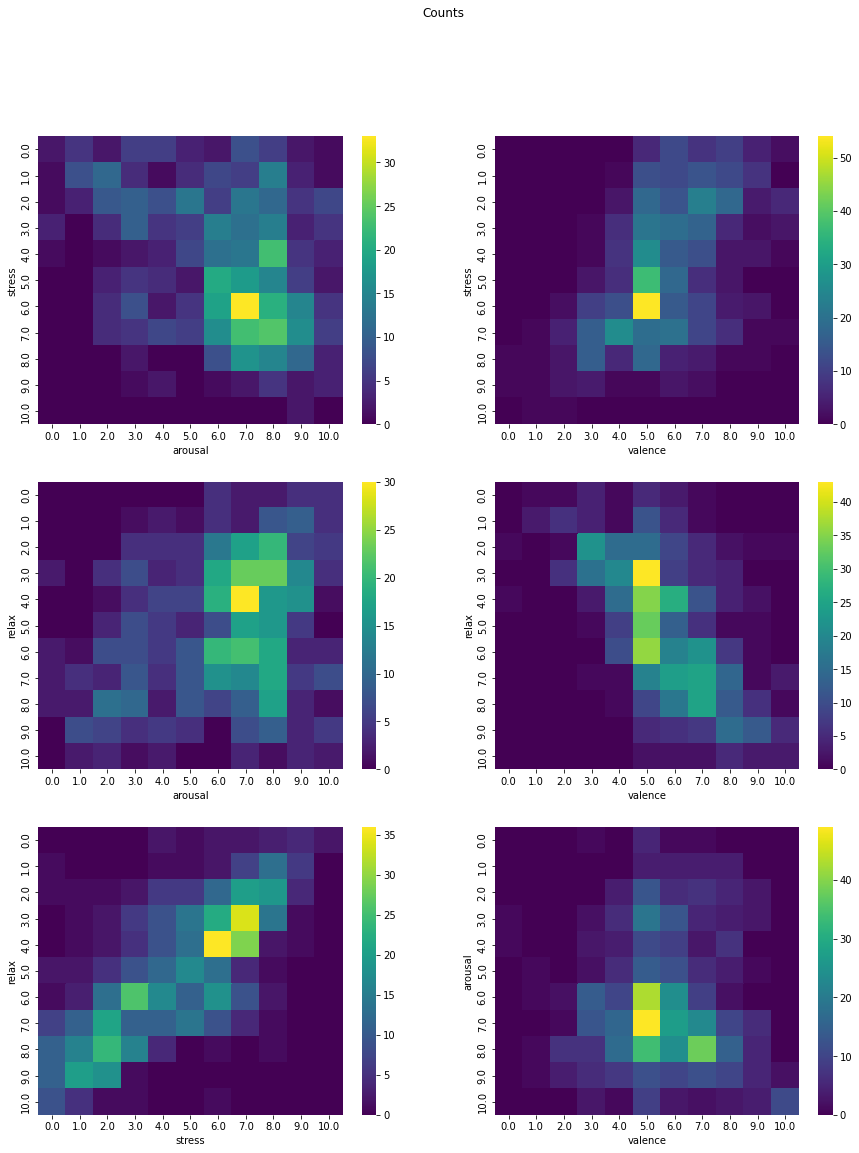

In [6]:
cross_stressarousal = pd.crosstab(labels_t.stress, labels_t.arousal)
cross_stressvalence = pd.crosstab(labels_t.stress, labels_t.valence)
cross_relaxarousal = pd.crosstab(labels_t.relax, labels_t.arousal)
cross_relaxvalence = pd.crosstab(labels_t.relax, labels_t.valence)
cross_relaxstress = pd.crosstab(labels_t.relax, labels_t.stress)
cross_arousalvalence = pd.crosstab(labels_t.arousal, labels_t.valence)

fig, axs = plt.subplots(3,2, figsize=(15, 18))
fig.suptitle('Counts')
sns.heatmap(ax=axs[0,0], data=cross_stressarousal, cmap="viridis")
sns.heatmap(ax=axs[0,1], data=cross_stressvalence, cmap="viridis")
sns.heatmap(ax=axs[1,0], data=cross_relaxarousal, cmap="viridis")
sns.heatmap(ax=axs[1,1], data=cross_relaxvalence, cmap="viridis")
sns.heatmap(ax=axs[2,0], data=cross_relaxstress, cmap="viridis")
sns.heatmap(ax=axs[2,1], data=cross_arousalvalence, cmap="viridis")
plt.show()

In [31]:
fig = px.density_heatmap(labels_t, 
                       labels_t.arousal, 
                       labels_t.stress, 
                       color_continuous_scale=px.colors.sequential.Viridis,
                       marginal_x="histogram", 
                       marginal_y="histogram",
                       width=500, height=500
                      )
fig.update_layout(font=dict(size=16))

In [32]:
fig = px.density_heatmap(labels_t, 
                       labels_t.valence, 
                       labels_t.relax, 
                       color_continuous_scale=px.colors.sequential.Viridis,
                       marginal_x="histogram", 
                       marginal_y="histogram",
                       width=500, height=500
                      )
fig.update_layout(font=dict(size=16))

# Most stressful

In [9]:
most = most_st.T
most.drop('Tasks', inplace=True)
counts = list(most[44].value_counts())
task_list = list(most[44].value_counts().index)

(array([0, 1, 2, 3, 4, 5, 6]), <a list of 7 Text major ticklabel objects>)

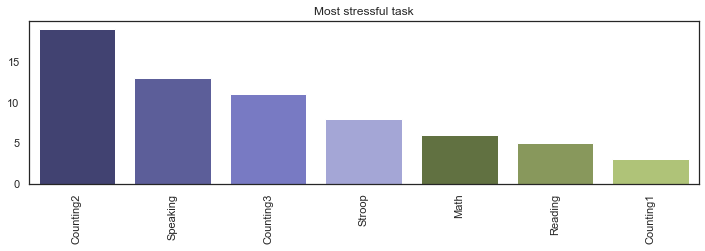

In [10]:
plt.figure(figsize=(12,3))
sns.set(style="white")
ax = sns.barplot(x=task_list, y=counts,  palette=sns.color_palette("tab20b"))
ax.title.set_text('Most stressful task')
plt.xticks(rotation=90)